In [1]:
!pip install pandas numpy matplotlib seaborn nltk wordcloud scikit-learn gradio

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report
import pickle

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Load Dataset

In [26]:
df=pd.read_csv('spam.csv',encoding='latin-1')

Display first five records

In [27]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Dataset Shape

In [28]:
df.shape

(5572, 5)

Dataset Information

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


Statistical Summary

In [30]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


Remove unnecessary columns

In [31]:
df.drop(
    columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],
    inplace=True
)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Rename columns

In [32]:
df.rename(
    columns={
        'v1': 'target',
        'v2': 'text'
    },
    inplace=True
)

df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Check Missing Values

In [33]:
df.isnull().sum()

,0
target,0
text,0


Check Duplicate Records

In [34]:
df.duplicated().sum()

np.int64(403)

Remove Duplicate Records

In [35]:
df = df.drop_duplicates()

df.shape

(5169, 2)

Encode Target Variable

In [36]:
encoder = LabelEncoder()

df['target'] = encoder.fit_transform(df['target'])

df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Distribution of Spam and Ham Messages

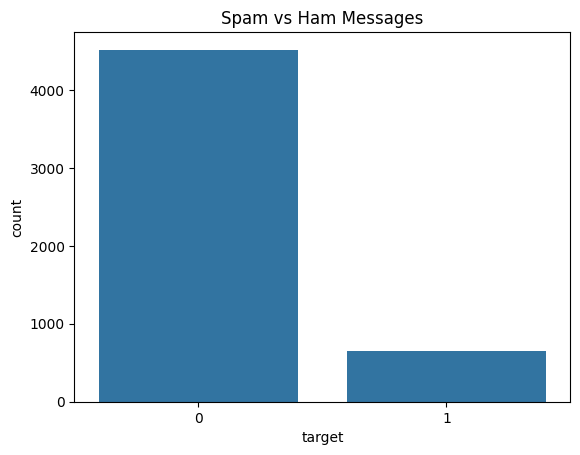

In [37]:
sns.countplot(x=df['target'])
plt.title("Spam vs Ham Messages")
plt.show()

Character Count Feature

In [38]:
df['char_count'] = df['text'].apply(len)

df.head()

,target,text,char_count
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


Word Count Feature

In [40]:
nltk.download('punkt_tab')
df['word_count'] = df['text'].apply(
    lambda x: len(word_tokenize(x))
)

df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,target,text,char_count,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


Message Length Analysis

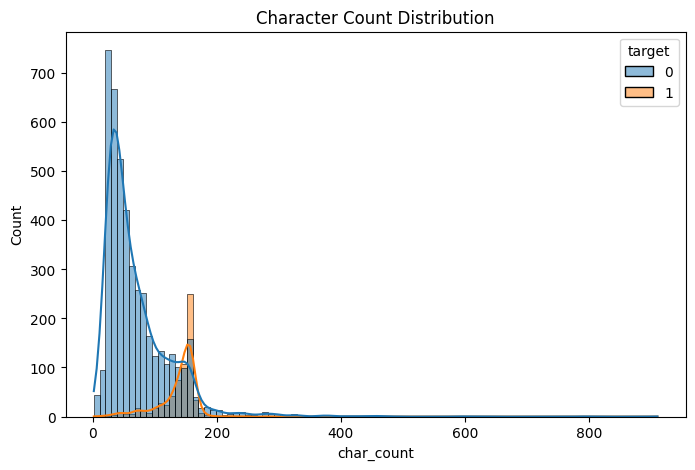

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='char_count',
    hue='target',
    kde=True
)

plt.title("Character Count Distribution")
plt.show()

Spam WordCloud

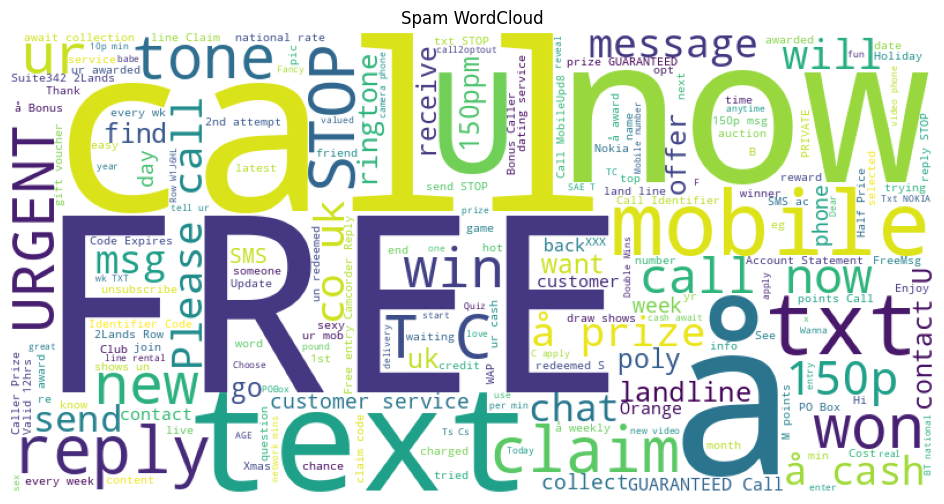

In [42]:
spam_text = " ".join(
    df[df['target']==1]['text']
)

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
)

spam_wc = wc.generate(spam_text)

plt.figure(figsize=(12,6))
plt.imshow(spam_wc)
plt.axis("off")
plt.title("Spam WordCloud")
plt.show()

Ham WordCloud

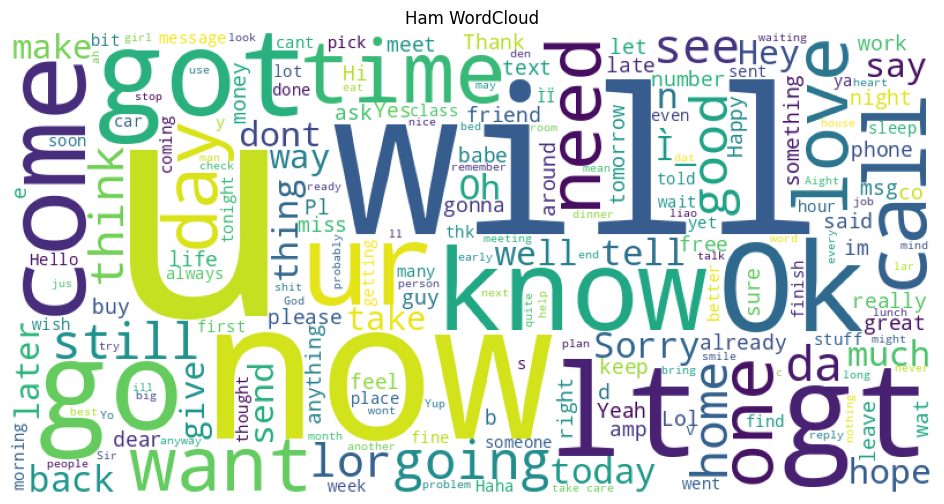

In [43]:
ham_text = " ".join(
    df[df['target']==0]['text']
)

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
)

ham_wc = wc.generate(ham_text)

plt.figure(figsize=(12,6))
plt.imshow(ham_wc)
plt.axis("off")
plt.title("Ham WordCloud")
plt.show()

Text Preprocessing

In [44]:
ps = PorterStemmer()

stop_words = set(stopwords.words('english'))

In [45]:
def transform_text(text):

    text = text.lower()

    words = word_tokenize(text)

    processed_words = []

    for word in words:

        if word.isalnum() and word not in stop_words:

            processed_words.append(
                ps.stem(word)
            )

    return " ".join(processed_words)

Apply Text Preprocessing

In [46]:
df['transformed_text'] = df['text'].apply(
    transform_text
)

df.head()

,target,text,char_count,word_count,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,nah think goe usf live around though


WordCloud After Cleaning (Spam)

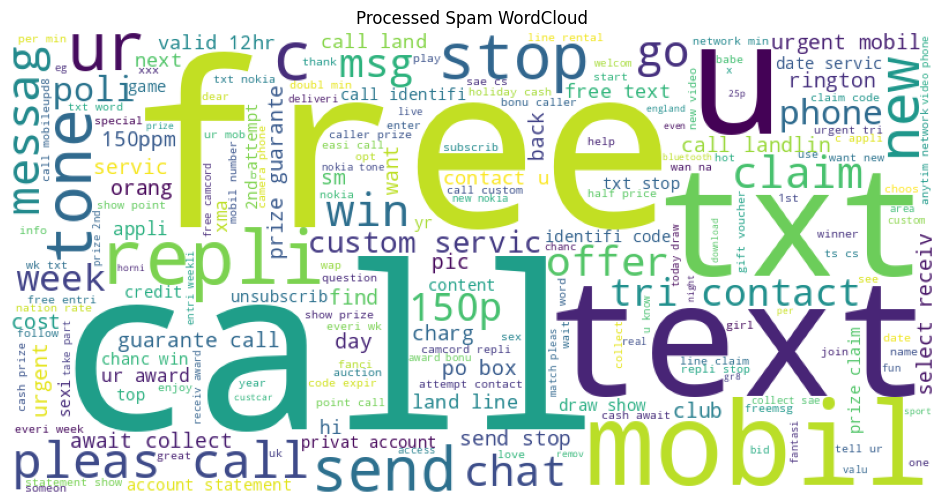

In [47]:
spam_text = " ".join(
    df[df['target']==1]['transformed_text']
)

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
)

spam_wc = wc.generate(spam_text)

plt.figure(figsize=(12,6))
plt.imshow(spam_wc)
plt.axis("off")
plt.title("Processed Spam WordCloud")
plt.show()

TF-IDF Vectorization

In [48]:
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(
    df['transformed_text']
)

Create Target Variable

In [49]:
y = df['target'].values

Train-Test Split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Naive Bayes Model

In [51]:
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

MultinomialNB()

Prediction

In [52]:
y_pred = model.predict(X_test)

Accuracy Score

In [53]:
accuracy_score(
    y_test,
    y_pred
)

0.9738878143133463

Precision Score

In [ ]:
precision_score(
    y_test,
    y_pred
)

Confusion Matrix

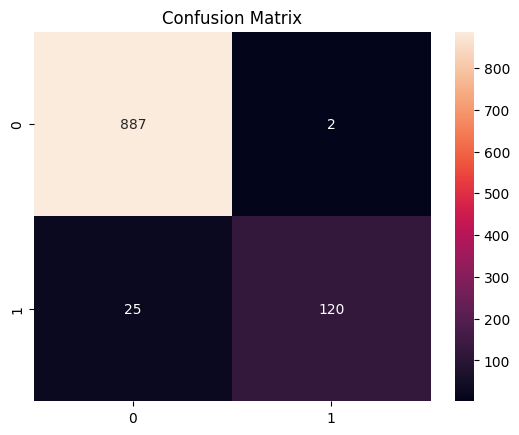

In [57]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

Classification Report

In [58]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       0.98      0.83      0.90       145

    accuracy                           0.97      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034



Save Vectorizer

In [59]:
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

Save Model

In [60]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

Load Saved Files

In [61]:
model = pickle.load(
    open("model.pkl", "rb")
)

vectorizer = pickle.load(
    open("vectorizer.pkl", "rb")
)

Test Prediction Function

In [62]:
def predict_spam(message):

    transformed = transform_text(message)

    vector_input = vectorizer.transform(
        [transformed]
    )

    result = model.predict(
        vector_input
    )[0]

    if result == 1:
        return "Spam"
    else:
        return "Ham"

Example Prediction

In [63]:
predict_spam(
    "Congratulations! You won a free iPhone. Click now."
)

'Spam'

Gradio Application

In [65]:
import gradio as gr
def classify_sms(message):

    transformed = transform_text(message)

    vector_input = vectorizer.transform(
        [transformed]
    )

    prediction = model.predict(
        vector_input
    )[0]

    if prediction == 1:
        return "Spam Message"
    else:
        return "Ham Message"

interface = gr.Interface(
    fn=classify_sms,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter SMS message..."
    ),
    outputs="text",
    title="SMS Spam Detector",
    description="Detect whether an SMS is Spam or Ham using Naive Bayes"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://79216403532efb8134.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
